# Algoritmo Guloso Ponderado por Notas (Ratings)

Este notebook implementa três variações do algoritmo guloso que levam em consideração as notas/ratings dos filmes durante a seleção, criando um trade-off entre cobertura de atores e qualidade dos filmes.

# Estratégias Implementadas

1. **Guloso com Restrição de Nota Mínima**: Seleciona apenas filmes com nota >= limite especificado, depois aplica cobertura máxima
2. **Guloso com Heurística Ponderada**: Combina cobertura e qualidade em um score ponderado
3. **Guloso Randomizado com Viés em Ratings**: Escolhas probabilísticas baseadas em cobertura e qualidade

In [1]:
import networkx as nx
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import sys
import os

#adicionar caminhos para importacoes
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

#importar funcoes do modulo
from greedy_weighted_rating import (
    greedy_weighted_rating_constraint,
    greedy_weighted_rating_heuristic,
    greedy_randomized_rating,
    movie_rating,
)

## Carregamento do Grafo e Setup

In [2]:
SEED = 42
N_RUNS = 50
GRAPHML_PATH = "../../graphs-and-analysis/instancias/grafo_bipartido.graphml"

print("Carregando grafo...")
G = nx.read_graphml(GRAPHML_PATH)
print(f"Grafo carregado: {G.number_of_nodes()} nós, {G.number_of_edges()} arestas\n")

movie_nodes = {n for n, d in G.nodes(data=True) if d.get("tipo") == "filme"}
actor_nodes = {n for n, d in G.nodes(data=True) if d.get("tipo") == "ator"}

print(f"Filmes: {len(movie_nodes)}")
print(f"Atores: {len(actor_nodes)}")

# Estatísticas de ratings
ratings = [movie_rating(G, m) for m in movie_nodes]
print(f"\nRatings dos filmes:")
print(f"  Mín: {np.min(ratings):.2f}")
print(f"  Máx: {np.max(ratings):.2f}")
print(f"  Média: {np.mean(ratings):.2f}")
print(f"  Mediana: {np.median(ratings):.2f}")

Carregando grafo...
Grafo carregado: 28349 nós, 48241 arestas

Filmes: 9671
Atores: 18678

Ratings dos filmes:
  Mín: 2.80
  Máx: 9.40
  Média: 6.66
  Mediana: 6.70


## Seleção de Subset de Atores

In [3]:
# Definir funções para extrair subsets (mesmas do traversal)

def find_node_by_label(G, name_fragment, node_type=None):
    results = []
    for n, d in G.nodes(data=True):
        if node_type and d.get("tipo") != node_type:
            continue
        if name_fragment.lower() in str(d.get("label", "")).lower():
            results.append((n, d))
    return results

def resolve_actors(names: list) -> set:
    ids = set()
    for name in names:
        matches = find_node_by_label(G, name, node_type="ator")
        if matches:
            best = max(matches, key=lambda x: G.degree(x[0]))
            ids.add(best[0])
    return ids

OSCAR_ACTING_NAMES = [
    "Will Smith", "Javier Bardem", "Benedict Cumberbatch",
    "Andrew Garfield", "Denzel Washington",
    "Troy Kotsur", "Ciarán Hinds", "Jesse Plemons",
    "J.K. Simmons", "Kodi Smit-McPhee",
    "Jessica Chastain", "Olivia Colman", "Penélope Cruz",
    "Nicole Kidman", "Kristen Stewart",
    "Ariana DeBose", "Jessie Buckley", "Judi Dench",
    "Kirsten Dunst", "Aunjanue Ellis",
    "Brendan Fraser", "Austin Butler", "Colin Farrell",
    "Paul Mescal", "Bill Nighy",
    "Ke Huy Quan", "Brendan Gleeson", "Brian Tyree Henry",
    "Judd Hirsch", "Barry Keoghan",
    "Michelle Yeoh", "Cate Blanchett", "Ana de Armas",
    "Andrea Riseborough", "Michelle Williams",
    "Jamie Lee Curtis", "Angela Bassett", "Hong Chau",
    "Kerry Condon", "Stephanie Hsu",
    "Cillian Murphy", "Bradley Cooper", "Colman Domingo",
    "Paul Giamatti", "Jeffrey Wright",
    "Robert Downey Jr.", "Sterling K. Brown", "Robert De Niro",
    "Ryan Gosling", "Mark Ruffalo",
    "Emma Stone", "Annette Bening", "Lily Gladstone",
    "Sandra Hüller", "Carey Mulligan",
    "Da'Vine Joy Randolph", "Emily Blunt", "Danielle Brooks",
    "America Ferrera", "Jodie Foster",
]

OSCAR_ACTORS_IDS = resolve_actors(OSCAR_ACTING_NAMES)

def get_female_actors(G) -> set:
    return {
        n for n, d in G.nodes(data=True)
        if d.get("tipo") == "ator" and d.get("genero") == "feminino"
    }

def get_brazilian_actors(G) -> set:
    return {
        n for n, d in G.nodes(data=True)
        if d.get("tipo") == "ator" and "Brazil" in str(d.get("local_nascimento", ""))
    }

def get_oscar_actors(G, oscar_actor_ids: set) -> set:
    return {n for n in oscar_actor_ids if n in G.nodes}

def get_genz_actors(G) -> set:
    genz = set()
    for n, d in G.nodes(data=True):
        if d.get("tipo") == "ator":
            nascimento = str(d.get("data_nascimento", "")).strip()
            if len(nascimento) >= 10 and "1997-01-01" <= nascimento[:10] <= "2012-12-31":
                genz.add(n)
    return genz

def get_deceased_actors(G) -> set:
    return {
        n for n, d in G.nodes(data=True)
        if d.get("tipo") == "ator" and str(d.get("morto", "")).strip() == "Sim"
    }

# Define os subsets a serem analisados
subsets = {
    "Atores Brasileiros": get_brazilian_actors(G),
    "Atrizes (feminino)": get_female_actors(G),
    "Indicados Oscar (atores)": get_oscar_actors(G, OSCAR_ACTORS_IDS),
    "Geracao Z": get_genz_actors(G),
    "Atores Falecidos": get_deceased_actors(G),
}

# Filtra subsets vazios
subsets = {k: v for k, v in subsets.items() if len(v) > 0}

print("Subsets a serem analisados:")
for name, subset in subsets.items():
    print(f"  {name}: {len(subset)} atores")

Subsets a serem analisados:
  Atores Brasileiros: 78 atores
  Atrizes (feminino): 7316 atores
  Indicados Oscar (atores): 59 atores
  Geracao Z: 1111 atores
  Atores Falecidos: 3032 atores


## Estratégia 1: Guloso com Restrição de Nota Mínima

In [4]:
# Teste de todas as estratégias para todos os subsets

all_subset_results = {}

for subset_name in subsets.keys():
    target_actors = subsets[subset_name]
    print(f"\nTestando: {subset_name} ({len(target_actors)} atores)\n")
    
    all_subset_results[subset_name] = {}
    
    # Estratégia 1: Restrição de nota mínima
    min_ratings_to_test = [0.0, 3.0, 5.0, 6.0, 7.0, 8.0]
    results_constraint = []
    
    for min_rating in min_ratings_to_test:
        result = greedy_weighted_rating_constraint(
            G,
            target_actors,
            min_rating=min_rating,
            candidate_movies=movie_nodes,
        )
        result["min_rating"] = min_rating
        results_constraint.append(result)
    
    all_subset_results[subset_name]["constraint"] = results_constraint
    
    # Estratégia 2: Heurística ponderada
    weight_configs = [(1.0, 0.0), (0.5, 0.5), (0.0, 1.0)]
    results_heuristic = {}
    
    for w_cov, w_rat in weight_configs:
        if w_cov == 0.0 and w_rat == 0.0:
            continue
        
        result = greedy_weighted_rating_heuristic(
            G,
            target_actors,
            weight_coverage=w_cov,
            weight_rating=w_rat,
            candidate_movies=movie_nodes,
        )
        
        config_name = f"Cov:{w_cov}, Rat:{w_rat}"
        results_heuristic[config_name] = result
    
    all_subset_results[subset_name]["heuristic"] = results_heuristic
    
    # Estratégia 3: Guloso Randomizado
    rating_weights = [0.5, 1.0, 2.0]
    n_runs = 20
    results_randomized = {}
    
    for rating_weight in rating_weights:
        runs = []
        print(f"  Rating Weight {rating_weight}...", end="\r")
        
        for seed in range(n_runs):
            result = greedy_randomized_rating(
                G,
                target_actors,
                rating_weight=rating_weight,
                candidate_movies=movie_nodes,
                seed=seed,
            )
            runs.append(result)
        
        n_films_vals = [r["n_films"] for r in runs]
        ratings_vals = [r["avg_rating"] for r in runs]
        
        results_randomized[rating_weight] = {
            "runs": runs,
            "n_films_mean": np.mean(n_films_vals),
            "n_films_std": np.std(n_films_vals),
            "avg_rating_mean": np.mean(ratings_vals),
            "avg_rating_std": np.std(ratings_vals),
        }
    
    all_subset_results[subset_name]["randomized"] = results_randomized
    print(f"  Completo: {subset_name}          ")


Testando: Atores Brasileiros (78 atores)

  Completo: Atores Brasileiros          

Testando: Atrizes (feminino) (7316 atores)

  Completo: Atrizes (feminino)          

Testando: Indicados Oscar (atores) (59 atores)

  Completo: Indicados Oscar (atores)          

Testando: Geracao Z (1111 atores)

  Completo: Geracao Z          

Testando: Atores Falecidos (3032 atores)

  Completo: Atores Falecidos          


## Estratégia 2: Guloso com Heurística Ponderada

In [5]:
# Testa diferentes pesos (coverage, rating)
weight_configs = [
    (1.0, 0.0),  # apenas cobertura
    (0.5, 0.5),  # balanceado
    (0.0, 1.0),  # apenas rating (impossível, resultará em erro)
]

results_heuristic = {}

for w_cov, w_rat in weight_configs:
    if w_cov == 0.0 and w_rat == 0.0:
        continue
    
    result = greedy_weighted_rating_heuristic(
        G,
        target_actors,
        weight_coverage=w_cov,
        weight_rating=w_rat,
        candidate_movies=movie_nodes,
    )
    
    config_name = f"Cov:{w_cov}, Rat:{w_rat}"
    results_heuristic[config_name] = result
    
    print(f"Configuração {config_name}:")
    print(f"  Filmes: {result['n_films']}")
    print(f"  Nota Média: {result['avg_rating']:.3f}")
    print(f"  Atores cobertos: {len(target_actors) - result['uncovered']}")
    print()

Configuração Cov:1.0, Rat:0.0:
  Filmes: 1487
  Nota Média: 6.904
  Atores cobertos: 3032

Configuração Cov:0.5, Rat:0.5:
  Filmes: 1501
  Nota Média: 6.989
  Atores cobertos: 3032

Configuração Cov:0.0, Rat:1.0:
  Filmes: 1721
  Nota Média: 7.064
  Atores cobertos: 3032



## Estratégia 3: Guloso Randomizado com Viés em Ratings

In [6]:
# Testa diferentes rating_weights com múltiplas runs
rating_weights = [0.5, 1.0, 2.0]
n_runs = 20

results_randomized = {}

for rating_weight in rating_weights:
    runs = []
    print(f"Rating Weight {rating_weight}:")
    
    for seed in range(n_runs):
        print(f"  Run {seed+1}/{n_runs}...", end="\r")
        result = greedy_randomized_rating(
            G,
            target_actors,
            rating_weight=rating_weight,
            candidate_movies=movie_nodes,
            seed=seed,
        )
        runs.append(result)
    
    n_films_vals = [r["n_films"] for r in runs]
    ratings_vals = [r["avg_rating"] for r in runs]
    
    results_randomized[rating_weight] = {
        "runs": runs,
        "n_films_mean": np.mean(n_films_vals),
        "n_films_std": np.std(n_films_vals),
        "avg_rating_mean": np.mean(ratings_vals),
        "avg_rating_std": np.std(ratings_vals),
    }
    
    print(f"Rating Weight {rating_weight}:              ")
    print(f"  Filmes: {np.mean(n_films_vals):.1f} ± {np.std(n_films_vals):.1f}")
    print(f"  Nota Média: {np.mean(ratings_vals):.3f} ± {np.std(ratings_vals):.3f}")
    print()

Rating Weight 0.5:
Rating Weight 0.5:              
  Filmes: 1646.2 ± 9.5
  Nota Média: 6.911 ± 0.008

Rating Weight 1.0:
Rating Weight 1.0:              
  Filmes: 1643.8 ± 10.5
  Nota Média: 6.914 ± 0.007

Rating Weight 2.0:
Rating Weight 2.0:              
  Filmes: 1641.5 ± 8.6
  Nota Média: 6.925 ± 0.005



## Comparação de Estratégias

In [7]:
# Cria tabela de comparação
comparison_data = []

# Adiciona resultados de restrição de nota mínima
for res in results_constraint:
    if res["feasible"]:
        comparison_data.append({
            "Estratégia": f"Restrição Min={res['min_rating']:.1f}",
            "Filmes": res["n_films"],
            "Nota Média": res["avg_rating"],
            "Nota Min": res["min_rating_achieved"],
        })

# Adiciona resultados da heurística ponderada
for config_name, res in results_heuristic.items():
    if res["uncovered"] == 0:
        comparison_data.append({
            "Estratégia": f"Heurística {config_name}",
            "Filmes": res["n_films"],
            "Nota Média": res["avg_rating"],
            "Nota Min": res["min_rating_achieved"],
        })

# Adiciona resultados randomizados (média)
for rating_weight, stats in results_randomized.items():
    comparison_data.append({
        "Estratégia": f"Randomizado W={rating_weight}",
        "Filmes": f"{stats['n_films_mean']:.1f}±{stats['n_films_std']:.1f}",
        "Nota Média": f"{stats['avg_rating_mean']:.3f}±{stats['avg_rating_std']:.3f}",
        "Nota Min": "-",
    })

df_comparison = pd.DataFrame(comparison_data)
print("\nComparação de Estratégias:")
print(df_comparison.to_string(index=False))


Comparação de Estratégias:
                 Estratégia      Filmes  Nota Média Nota Min
          Restrição Min=0.0        1578    6.920914      2.8
Heurística Cov:1.0, Rat:0.0        1497    6.916662      2.8
Heurística Cov:0.5, Rat:0.5        1501    6.988833      2.8
Heurística Cov:0.0, Rat:1.0        1721    7.063681      2.8
          Randomizado W=0.5 1649.5±10.8 6.909±0.007        -
          Randomizado W=1.0  1646.5±9.3 6.914±0.007        -
          Randomizado W=2.0  1639.7±9.5 6.926±0.006        -


## Visualizações

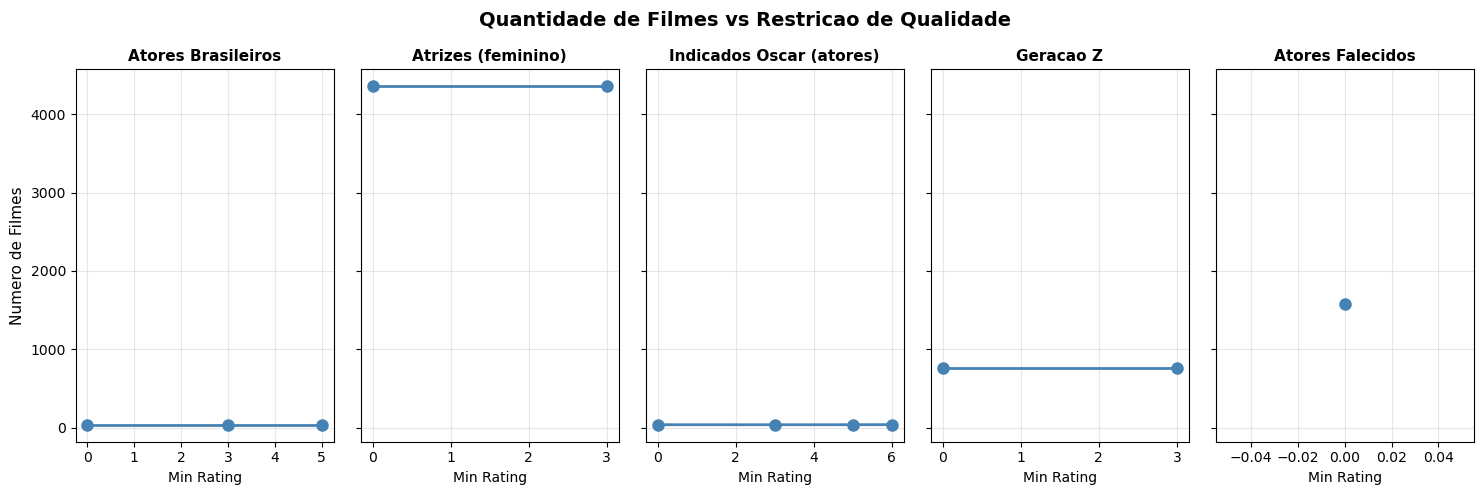

Grafico salvo: greedy_constraint_by_subset.png


In [8]:

# Gráficos Comparativos: Todos os Subsets

# Comparação 1: Quantidade de filmes (Restrição de Nota Mínima)
fig, axes = plt.subplots(1, len(subsets), figsize=(15, 5), sharey=True)
if len(subsets) == 1:
    axes = [axes]

for ax, (name, _) in zip(axes, subsets.items()):
    constraint_results = all_subset_results[name]["constraint"]
    feasible = [r for r in constraint_results if r["feasible"]]
    
    if feasible:
        min_ratings_vals = [r["min_rating"] for r in feasible]
        n_films_vals = [r["n_films"] for r in feasible]
        ax.plot(min_ratings_vals, n_films_vals, 'o-', linewidth=2, markersize=8, color='steelblue')
    
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel("Min Rating", fontsize=10)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Numero de Filmes", fontsize=11)
fig.suptitle("Quantidade de Filmes vs Restricao de Qualidade", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("greedy_constraint_by_subset.png", dpi=150, bbox_inches='tight')
plt.show()

print("Grafico salvo: greedy_constraint_by_subset.png")


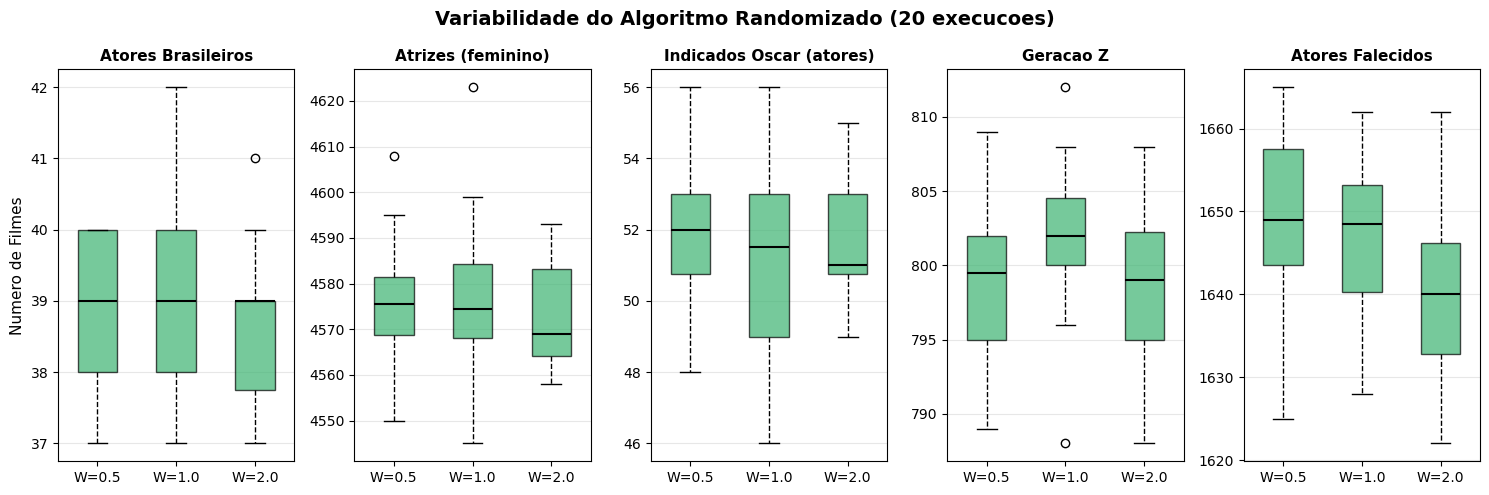

Grafico salvo: greedy_randomized_by_subset.png


In [9]:

# Comparação 2: Boxplot de Quantidade (Algoritmo Randomizado)

subsets_names = list(subsets.keys())
n_subsets = len(subsets_names)

fig, axes = plt.subplots(1, n_subsets, figsize=(15, 5), sharey=False)
if n_subsets == 1:
    axes = [axes]

for ax, subset_name in zip(axes, subsets_names):
    randomized_results = all_subset_results[subset_name]["randomized"]
    
    n_films_data = [
        [r["n_films"] for r in randomized_results[w]["runs"]]
        for w in randomized_results.keys()
    ]
    
    bp = ax.boxplot(
        n_films_data,
        widths=0.5,
        patch_artist=True,
        boxprops=dict(facecolor='mediumseagreen', alpha=0.7),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(linestyle='--')
    )
    
    ax.set_title(subset_name, fontsize=11, fontweight='bold')
    ax.set_xticklabels([f"W={w}" for w in randomized_results.keys()])
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel("Numero de Filmes", fontsize=11)
fig.suptitle("Variabilidade do Algoritmo Randomizado (20 execucoes)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("greedy_randomized_by_subset.png", dpi=150, bbox_inches='tight')
plt.show()

print("Grafico salvo: greedy_randomized_by_subset.png")
